# IRIS: Introspective Reliability-Gated Instance Selection
## Human-in-the-Loop Deep Active Learning under Imperfect Annotators

**Self-contained project notebook** — code, experiments, and results in one file.

### The idea in three bullets
- **Introspection head**: a 2-layer MLP on the backbone's *detached* penultimate
  features, trained jointly (class-balanced BCE) to predict *the probability that the
  main classifier is wrong* on an input — a learned, bounded, calibrated acquisition
  signal replacing hand-crafted softmax entropy.
- **Diversity gate**: the top β·K introspection-ranked pool samples are filtered to K by
  greedy k-center selection in feature space (seeded with the already-labeled set), so
  each human-annotation batch is informative *and* non-redundant.
- **Reliability-weighted training**: per-sample EMA losses drive small-loss weighting
  (co-teaching principle), so labels bought from a *noisy* human annotator (γ = 0.2)
  don't poison the model.

### Experimental protocol
Pool-based batch AL on **Fashion-MNIST** (500 + 5×500 labels, small CNN) and
**CIFAR-10** (1000 + 5×1000 labels, ResNet-18) against **random / entropy / BALD /
core-set** baselines, under a **clean** and a **noisy (γ=0.2)** simulated annotator,
3 seeds each; metrics: accuracy-vs-budget curves, final accuracy, AUBC, plus an
error-prediction AUROC audit of the introspection head.

### Project layout
```
HITL/
├── papers/              # 21 downloaded PDFs (2026 Q1 papers + foundations)
├── literature_review/   # literature_review.md + per-source metadata
├── code/                # hitl_experiments.py, make_plots.py, make_numbers.py, finalize.sh
├── results/             # results.csv, summary tables, figures  (auto-generated)
├── latex/               # main.tex → main.pdf (numbers auto-filled from results)
├── logs/                # experiments.log (the nohup run), finalize.log
└── HITL_IRIS.ipynb      # this notebook
```


## 1. Experiment implementation
The complete implementation (identical to `code/hitl_experiments.py`). Running this cell only *defines* everything — no training starts.

In [1]:
"""
IRIS: Introspective Reliability-gated Instance Selection for
Human-in-the-Loop Deep Active Learning.

Runs the full experimental grid:
  datasets : Fashion-MNIST, CIFAR-10, BloodMNIST (MedMNIST v2)
  methods  : random, entropy, bald, coreset, iris
             (+ diversity/reliability ablations on the two 28x28 datasets)
  oracle   : clean (noise=0.0) and noisy human annotator (noise=0.2)
  seeds    : 0, 1, 2

Results are appended incrementally to results/results.csv so partial
progress is never lost.  Designed to run unattended under nohup.
"""

import argparse
import json
import os
import random
import subprocess
import sys
import time
import traceback

import numpy as np
import torch
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import resnet18

try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:  # running inside a notebook: cwd is the project root
    ROOT = os.getcwd()
DATA_DIR = os.path.join(ROOT, "code", "data")
RESULTS_DIR = os.path.join(ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_CSV = os.path.join(RESULTS_DIR, "results.csv")
DIAG_CSV = os.path.join(RESULTS_DIR, "diagnostics.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BLOOD_NPZ = os.path.join(DATA_DIR, "bloodmnist.npz")

# per-dataset input shape / label space / backbone choice
DATASET_SPECS = {
    "fmnist":     dict(num_classes=10, in_ch=1, backbone="smallcnn"),
    "cifar10":    dict(num_classes=10, in_ch=3, backbone="resnet18"),
    "bloodmnist": dict(num_classes=8,  in_ch=3, backbone="smallcnn"),
}


# --------------------------------------------------------------------------
# Reproducibility
# --------------------------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# --------------------------------------------------------------------------
# Data
# --------------------------------------------------------------------------
def get_datasets(name):
    if name == "fmnist":
        tf_train = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        train_aug = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf_train)
        train_plain = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf_test)
        test = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=tf_test)
    elif name == "cifar10":
        mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        tf_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        train_aug = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=tf_train)
        train_plain = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=tf_test)
        test = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=tf_test)
    elif name == "bloodmnist":
        # MedMNIST v2 blood-cell microscopy: 8 leukocyte classes, 28x28 RGB,
        # 11,959 train / 3,421 test. Stands in for the expert-annotation
        # regime the paper targets: a competent base model, a specialist
        # oracle, and a modest label budget.
        mean, std = (0.8162, 0.6685, 0.6955), (0.2152, 0.2415, 0.1175)
        tf_train = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        train_aug = NpzImageDataset(BLOOD_NPZ, "train", tf_train)
        train_plain = NpzImageDataset(BLOOD_NPZ, "train", tf_test)
        test = NpzImageDataset(BLOOD_NPZ, "test", tf_test)
    else:
        raise ValueError(name)
    return train_aug, train_plain, test


class NpzImageDataset(Dataset):
    """A MedMNIST-style .npz split (images NHWC uint8, labels Nx1) exposed
    with the same interface as the torchvision datasets above."""

    def __init__(self, path, split, transform):
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"{path} missing - fetch it with:\n  curl -L -o {path} "
                "https://zenodo.org/records/10519652/files/bloodmnist.npz")
        d = np.load(path)
        self.images = d[f"{split}_images"]
        self.targets = [int(t) for t in d[f"{split}_labels"].ravel()]
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        return self.transform(Image.fromarray(self.images[i])), self.targets[i]


class LabeledSubset(Dataset):
    """Subset of a base dataset with (possibly noisy) oracle labels and stable
    per-sample ids so the trainer can track per-sample EMA losses."""

    def __init__(self, base, indices, labels):
        self.base = base
        self.indices = list(indices)
        self.labels = list(labels)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, _ = self.base[self.indices[i]]
        return x, self.labels[i], i


# --------------------------------------------------------------------------
# Models: backbone returns (logits, penultimate_features);
# IntrospectionHead is the auxiliary error-prediction branch.
# --------------------------------------------------------------------------
class SmallCNN(nn.Module):
    """Compact CNN for the 28x28 datasets (Fashion-MNIST, BloodMNIST).
    Penultimate feature dim = 256."""

    feat_dim = 256

    def __init__(self, num_classes=10, in_ch=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc1 = nn.Linear(64 * 7 * 7, self.feat_dim)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x):
        h = self.features(x).flatten(1)
        feat = F.relu(self.fc1(h))
        logits = self.fc2(self.dropout(feat))
        return logits, feat


class ResNet18C(nn.Module):
    """ResNet-18 adapted to 32x32 inputs. Penultimate feature dim = 512."""

    feat_dim = 512

    def __init__(self, num_classes=10):
        super().__init__()
        net = resnet18(num_classes=num_classes)
        net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        net.maxpool = nn.Identity()
        self.stem = nn.Sequential(
            net.conv1, net.bn1, net.relu, net.maxpool,
            net.layer1, net.layer2, net.layer3, net.layer4, net.avgpool,
        )
        self.dropout = nn.Dropout(0.25)
        self.fc = net.fc

    def forward(self, x):
        feat = self.stem(x).flatten(1)
        logits = self.fc(self.dropout(feat))
        return logits, feat


class IntrospectionHead(nn.Module):
    """Auxiliary branch predicting P(main classifier is wrong) from
    (detached) penultimate features."""

    def __init__(self, feat_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, feat):
        return self.net(feat).squeeze(-1)


def make_model(dataset, seed):
    torch.manual_seed(seed)
    spec = DATASET_SPECS[dataset]
    if spec["backbone"] == "smallcnn":
        backbone = SmallCNN(num_classes=spec["num_classes"], in_ch=spec["in_ch"])
    else:
        backbone = ResNet18C(num_classes=spec["num_classes"])
    head = IntrospectionHead(backbone.feat_dim)
    return backbone.to(DEVICE), head.to(DEVICE)


# --------------------------------------------------------------------------
# Training with joint introspection head and optional reliability weighting
# --------------------------------------------------------------------------
def train_model(backbone, head, labeled_ds, cfg, use_reliability, noise_rate):
    epochs = cfg["epochs"]
    # a tiny trailing batch (e.g. 5000 % 128 = 8) destabilizes BatchNorm badly
    # enough to dent a whole round — drop it when degenerate
    drop_last = (len(labeled_ds) % cfg["batch_size"]) < 16
    loader = DataLoader(labeled_ds, batch_size=cfg["batch_size"], shuffle=True,
                        num_workers=2, drop_last=drop_last)
    params = list(backbone.parameters()) + list(head.parameters())
    opt = torch.optim.SGD(params, lr=cfg["lr"], momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    n = len(labeled_ds)
    ema_loss = torch.zeros(n, device=DEVICE)
    ema_init = torch.zeros(n, dtype=torch.bool, device=DEVICE)
    warmup = max(3, epochs // 5)
    err_rate = 0.5  # running estimate of P(error) for pos_weight balancing

    backbone.train()
    head.train()
    for ep in range(epochs):
        for x, y, idx in loader:
            x, y, idx = x.to(DEVICE), y.to(DEVICE), idx.to(DEVICE)
            logits, feat = backbone(x)
            per_sample = F.cross_entropy(logits, y, reduction="none")

            with torch.no_grad():
                cur = per_sample.detach()
                old = ema_loss[idx]
                ema_loss[idx] = torch.where(ema_init[idx], 0.7 * old + 0.3 * cur, cur)
                ema_init[idx] = True

            if use_reliability and ep >= warmup:
                # small-loss trick: keep the (1 - noise_rate) fraction with the
                # smallest EMA loss at full weight, down-weight the rest.
                k = max(1, int((1.0 - noise_rate) * per_sample.numel()))
                thresh = torch.kthvalue(ema_loss[idx], k).values
                w = torch.where(ema_loss[idx] <= thresh,
                                torch.ones_like(per_sample),
                                torch.full_like(per_sample, 0.1))
                cls_loss = (w * per_sample).sum() / w.sum()
            else:
                cls_loss = per_sample.mean()

            # introspection head: predict whether the main head is wrong,
            # on detached features so the auxiliary loss never disturbs the backbone
            with torch.no_grad():
                wrong = (logits.argmax(1) != y).float()
                err_rate = 0.95 * err_rate + 0.05 * wrong.mean().item()
            pos_weight = torch.tensor(
                min(20.0, max(1.0, (1 - err_rate) / max(err_rate, 1e-3))),
                device=DEVICE)
            aux_logit = head(feat.detach())
            aux_loss = F.binary_cross_entropy_with_logits(aux_logit, wrong,
                                                          pos_weight=pos_weight)

            opt.zero_grad()
            (cls_loss + aux_loss).backward()
            opt.step()
        sched.step()
    return backbone, head


# --------------------------------------------------------------------------
# Inference utilities
# --------------------------------------------------------------------------
@torch.no_grad()
def predict(backbone, ds, indices=None, batch_size=256):
    """Returns (probs, feats) in eval mode for the given indices of ds."""
    backbone.eval()
    if indices is None:
        indices = range(len(ds))
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    probs, feats = [], []
    for x, _ in loader:
        logits, feat = backbone(x.to(DEVICE))
        probs.append(F.softmax(logits, 1).cpu())
        feats.append(feat.cpu())
    return torch.cat(probs), torch.cat(feats)


@torch.no_grad()
def mc_dropout_probs(backbone, ds, indices, passes=10, batch_size=256):
    """MC-dropout predictive samples: dropout active, batchnorm frozen."""
    backbone.eval()
    for m in backbone.modules():
        if isinstance(m, nn.Dropout):
            m.train()
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    all_probs = []
    for _ in range(passes):
        chunk = []
        for x, _ in loader:
            logits, _ = backbone(x.to(DEVICE))
            chunk.append(F.softmax(logits, 1).cpu())
        all_probs.append(torch.cat(chunk))
    backbone.eval()
    return torch.stack(all_probs)  # [passes, N, C]


@torch.no_grad()
def introspection_scores(backbone, head, ds, indices, batch_size=256):
    backbone.eval()
    head.eval()
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    scores, feats = [], []
    for x, _ in loader:
        _, feat = backbone(x.to(DEVICE))
        scores.append(torch.sigmoid(head(feat)).cpu())
        feats.append(feat.cpu())
    return torch.cat(scores), torch.cat(feats)


@torch.no_grad()
def evaluate(backbone, test_ds, batch_size=256):
    backbone.eval()
    loader = DataLoader(test_ds, batch_size=batch_size, num_workers=2)
    correct = total = 0
    for x, y in loader:
        logits, _ = backbone(x.to(DEVICE))
        correct += (logits.argmax(1).cpu() == y).sum().item()
        total += y.numel()
    return correct / total


def kcenter_greedy(cand_feats, k, init_feats=None):
    """Greedy k-center over candidate features (optionally seeded with the
    already-labeled set's features). Returns positions into cand_feats."""
    cand = cand_feats.to(DEVICE)
    if init_feats is not None and len(init_feats) > 0:
        centers = init_feats.to(DEVICE)
        # chunk the candidate x center distance matrix to bound peak memory
        min_d = torch.full((cand.shape[0],), float("inf"), device=DEVICE)
        for s in range(0, centers.shape[0], 1024):
            d = torch.cdist(cand, centers[s:s + 1024]).min(1).values
            min_d = torch.minimum(min_d, d)
    else:
        first = 0
        min_d = torch.cdist(cand, cand[first:first + 1]).squeeze(1)
        picked = [first]
        while len(picked) < k:
            nxt = int(min_d.argmax())
            picked.append(nxt)
            d = torch.cdist(cand, cand[nxt:nxt + 1]).squeeze(1)
            min_d = torch.minimum(min_d, d)
        return picked
    picked = []
    while len(picked) < k:
        nxt = int(min_d.argmax())
        picked.append(nxt)
        d = torch.cdist(cand, cand[nxt:nxt + 1]).squeeze(1)
        min_d = torch.minimum(min_d, d)
    return picked


# --------------------------------------------------------------------------
# Acquisition functions: return positions into `pool` (a list of dataset idx)
# --------------------------------------------------------------------------
def acquire(method, k, backbone, head, plain_ds, pool, labeled_idx, rng):
    if method == "random":
        return list(rng.choice(len(pool), size=k, replace=False))

    if method == "entropy":
        probs, _ = predict(backbone, plain_ds, pool)
        ent = -(probs * probs.clamp_min(1e-12).log()).sum(1)
        return ent.topk(k).indices.tolist()

    if method == "bald":
        mc = mc_dropout_probs(backbone, plain_ds, pool, passes=10)
        mean_p = mc.mean(0)
        h_mean = -(mean_p * mean_p.clamp_min(1e-12).log()).sum(1)
        mean_h = -(mc * mc.clamp_min(1e-12).log()).sum(2).mean(0)
        mi = h_mean - mean_h
        return mi.topk(k).indices.tolist()

    if method == "coreset":
        _, pool_f = predict(backbone, plain_ds, pool)
        _, lab_f = predict(backbone, plain_ds, labeled_idx)
        return kcenter_greedy(pool_f, k, init_feats=lab_f)

    if method in ("iris", "iris-nodiv", "iris-norel"):
        scores, pool_f = introspection_scores(backbone, head, plain_ds, pool)
        if method == "iris-nodiv":
            return scores.topk(k).indices.tolist()
        beta = 5
        cand_pos = scores.topk(min(beta * k, len(pool))).indices
        _, lab_f = predict(backbone, plain_ds, labeled_idx)
        picked_in_cand = kcenter_greedy(pool_f[cand_pos], k, init_feats=lab_f)
        return [int(cand_pos[p]) for p in picked_in_cand]

    raise ValueError(method)


# --------------------------------------------------------------------------
# Noisy human oracle
# --------------------------------------------------------------------------
def oracle_labels(true_labels, noise_rate, num_classes, rng):
    labels = list(true_labels)
    if noise_rate > 0:
        for i in range(len(labels)):
            if rng.random() < noise_rate:
                wrong = [c for c in range(num_classes) if c != labels[i]]
                labels[i] = int(rng.choice(wrong))
    return labels


# --------------------------------------------------------------------------
# Diagnostics: does the introspection head actually predict errors?
# --------------------------------------------------------------------------
@torch.no_grad()
def error_prediction_auroc(backbone, head, test_ds):
    from sklearn.metrics import roc_auc_score
    backbone.eval(); head.eval()
    loader = DataLoader(test_ds, batch_size=256, num_workers=2)
    intro, ent, err = [], [], []
    for x, y in loader:
        logits, feat = backbone(x.to(DEVICE))
        p = F.softmax(logits, 1)
        intro.append(torch.sigmoid(head(feat)).cpu())
        ent.append(-(p * p.clamp_min(1e-12).log()).sum(1).cpu())
        err.append((logits.argmax(1).cpu() != y).float())
    intro, ent, err = torch.cat(intro), torch.cat(ent), torch.cat(err)
    if err.sum() == 0 or err.sum() == len(err):
        return float("nan"), float("nan")
    return (roc_auc_score(err.numpy(), intro.numpy()),
            roc_auc_score(err.numpy(), ent.numpy()))


# --------------------------------------------------------------------------
# One full active-learning run
# --------------------------------------------------------------------------
def append_csv(path, header, row):
    new = not os.path.exists(path)
    with open(path, "a") as f:
        if new:
            f.write(",".join(header) + "\n")
        f.write(",".join(str(v) for v in row) + "\n")
        f.flush()
        os.fsync(f.fileno())


RESULT_HEADER = ["dataset", "method", "noise", "seed", "round",
                 "n_labeled", "test_acc", "wall_s"]
DIAG_HEADER = ["dataset", "method", "noise", "seed", "round",
               "auroc_introspection", "auroc_entropy"]


def run_al(dataset, method, noise_rate, seed, cfg):
    t0 = time.time()
    set_seed(seed)
    rng = np.random.default_rng(seed)
    train_aug, train_plain, test = get_datasets(dataset)
    true_targets = [int(t) for t in (train_aug.targets if isinstance(train_aug.targets, list)
                                     else train_aug.targets.tolist())]
    n_train = len(train_aug)
    num_classes = DATASET_SPECS[dataset]["num_classes"]

    all_idx = rng.permutation(n_train)
    labeled_idx = list(all_idx[:cfg["init_labeled"]])
    pool = list(all_idx[cfg["init_labeled"]:])

    # the (possibly noisy) human oracle labels everything it is asked about
    labels = oracle_labels([true_targets[i] for i in labeled_idx],
                           noise_rate, num_classes, rng)
    oracle_map = dict(zip(labeled_idx, labels))

    use_rel = (method == "iris" and noise_rate > 0)

    for rnd in range(cfg["rounds"] + 1):
        backbone, head = make_model(dataset, seed * 1000 + rnd)
        labeled_ds = LabeledSubset(train_aug, labeled_idx,
                                   [oracle_map[i] for i in labeled_idx])
        train_model(backbone, head, labeled_ds, cfg, use_rel, noise_rate)
        acc = evaluate(backbone, test)
        append_csv(RESULTS_CSV, RESULT_HEADER,
                   [dataset, method, noise_rate, seed, rnd,
                    len(labeled_idx), f"{acc:.4f}", f"{time.time() - t0:.1f}"])
        if method.startswith("iris"):
            a_i, a_e = error_prediction_auroc(backbone, head, test)
            append_csv(DIAG_CSV, DIAG_HEADER,
                       [dataset, method, noise_rate, seed, rnd,
                        f"{a_i:.4f}", f"{a_e:.4f}"])
        print(f"[{dataset}|{method}|noise={noise_rate}|seed={seed}] "
              f"round {rnd}: n={len(labeled_idx)} acc={acc:.4f} "
              f"({time.time() - t0:.0f}s)", flush=True)

        if rnd == cfg["rounds"]:
            break
        picked_pos = acquire(method, cfg["query_size"], backbone, head,
                             train_plain, pool, labeled_idx, rng)
        picked = [pool[p] for p in picked_pos]
        new_labels = oracle_labels([true_targets[i] for i in picked],
                                   noise_rate, num_classes, rng)
        for i, l in zip(picked, new_labels):
            oracle_map[i] = l
        labeled_idx.extend(picked)
        pool = [i for i in pool if i not in set(picked)]

        del backbone, head
        torch.cuda.empty_cache()


# --------------------------------------------------------------------------
# GPU coexistence: this box is shared with other (untouchable) training jobs.
# Wait for enough free GPU memory before each run and back off on OOM.
# --------------------------------------------------------------------------
def gpu_free_mb():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.free",
             "--format=csv,noheader,nounits"], text=True)
        return int(out.strip().splitlines()[0])
    except Exception:
        return None


def wait_for_gpu(min_free_mb, poll_s=180, max_wait_s=12 * 3600):
    if not torch.cuda.is_available():
        return
    waited = 0
    while waited <= max_wait_s:
        free = gpu_free_mb()
        if free is None or free >= min_free_mb:
            return
        print(f"GPU busy ({free}MB free < {min_free_mb}MB needed) — "
              f"waiting {poll_s}s", flush=True)
        time.sleep(poll_s)
        waited += poll_s
    print("max GPU wait exceeded — attempting run anyway", flush=True)


# --------------------------------------------------------------------------
# Experiment grid
# --------------------------------------------------------------------------
CFGS = {
    "fmnist": dict(init_labeled=500, query_size=500, rounds=5,
                   epochs=30, batch_size=64, lr=0.02, min_free_mb=2500),
    "cifar10": dict(init_labeled=1000, query_size=1000, rounds=5,
                    epochs=30, batch_size=128, lr=0.05, min_free_mb=3500),
    "bloodmnist": dict(init_labeled=500, query_size=500, rounds=5,
                       epochs=30, batch_size=64, lr=0.02, min_free_mb=2500),
}

# datasets cheap enough to also carry the component ablations
ABLATION_DATASETS = ("fmnist", "bloodmnist")

BASE_METHODS = ["random", "entropy", "bald", "coreset", "iris"]


def already_done(dataset, method, noise, seed, rounds):
    """A run is complete if its final round is already in the CSV."""
    if not os.path.exists(RESULTS_CSV):
        return False
    key = f"{dataset},{method},{noise},{seed},{rounds},"
    with open(RESULTS_CSV) as f:
        return any(line.startswith(key) for line in f)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--datasets", nargs="+",
                    default=["fmnist", "cifar10", "bloodmnist"])
    ap.add_argument("--seeds", nargs="+", type=int, default=[0, 1, 2])
    ap.add_argument("--quick", action="store_true",
                    help="tiny smoke test: 1 seed, 1 round, 2 epochs")
    args = ap.parse_args()

    print(f"device={DEVICE} torch={torch.__version__}", flush=True)

    grid = []
    for ds in args.datasets:
        methods_clean = list(BASE_METHODS)
        methods_noisy = list(BASE_METHODS)
        if ds in ABLATION_DATASETS:  # ablations on the fast datasets
            methods_clean.append("iris-nodiv")
            methods_noisy.append("iris-norel")
        for noise, methods in ((0.0, methods_clean), (0.2, methods_noisy)):
            for m in methods:
                for s in args.seeds:
                    grid.append((ds, m, noise, s))

    if args.quick:
        grid = [("fmnist", m, 0.2, 0) for m in ("iris", "entropy")]

    print(f"grid: {len(grid)} runs", flush=True)
    for i, (ds, m, noise, seed) in enumerate(grid):
        cfg = dict(CFGS[ds])
        if args.quick:
            cfg.update(rounds=1, epochs=2, init_labeled=200, query_size=200)
        if not args.quick and already_done(ds, m, noise, seed, cfg["rounds"]):
            print(f"skip (done): {ds} {m} {noise} {seed}", flush=True)
            continue
        print(f"=== run {i + 1}/{len(grid)}: {ds} {m} noise={noise} seed={seed} ===",
              flush=True)
        for attempt in range(1, 5):
            wait_for_gpu(cfg.get("min_free_mb", 3000))
            try:
                run_al(ds, m, noise, seed, cfg)
                break
            except (torch.OutOfMemoryError, RuntimeError) as e:
                if "out of memory" not in str(e).lower():
                    traceback.print_exc()
                    print(f"RUN FAILED: {ds} {m} {noise} {seed} — continuing",
                          flush=True)
                    break
                torch.cuda.empty_cache()
                print(f"OOM (attempt {attempt}/4): {ds} {m} {noise} {seed} — "
                      f"backing off 10 min", flush=True)
                time.sleep(600)
            except Exception:
                traceback.print_exc()
                print(f"RUN FAILED: {ds} {m} {noise} {seed} — continuing",
                      flush=True)
                break

    print("ALL RUNS COMPLETE", flush=True)

## 2. Quick demo (~2 min on GPU)
Set `RUN_DEMO = True` to run a miniature AL loop (Fashion-MNIST, IRIS vs entropy, 1 round) and sanity-check the pipeline end-to-end.

In [2]:
RUN_DEMO = False
if RUN_DEMO:
    cfg = dict(init_labeled=500, query_size=500, rounds=1,
               epochs=15, batch_size=64, lr=0.02)
    for method in ("iris", "entropy"):
        run_al("fmnist", method, 0.2, 0, cfg)

## 3. Full experiment grid (long-running)
The full grid (3 datasets × ≥5 methods × 2 oracle noise levels × 3-6 seeds) is meant to run detached from any SSH session:
```bash
cd <project>/HITL
nohup /opt/miniconda/bin/python -u code/hitl_experiments.py > logs/experiments.log 2>&1 &
nohup bash code/finalize.sh > /dev/null 2>&1 &   # auto-rebuilds figures + PDF
tail -f logs/experiments.log                      # watch progress
```
Runs are resumable: completed (dataset, method, noise, seed) combinations found in `results/results.csv` are skipped on restart. Set `RUN_FULL = True` below to launch from the notebook instead (not recommended over SSH).

In [3]:
RUN_FULL = False
if RUN_FULL:
    import subprocess
    subprocess.Popen(
        ["nohup", "/opt/miniconda/bin/python", "-u", "code/hitl_experiments.py"],
        stdout=open("logs/experiments.log", "a"), stderr=subprocess.STDOUT,
        cwd=ROOT, start_new_session=True)
    print("launched — tail logs/experiments.log")

## 4. Results
Loads `results/results.csv` (written incrementally by the grid run) and reproduces every figure and table used in the paper.

In [4]:
import pandas as pd
res_path = os.path.join(RESULTS_DIR, "results.csv")
if os.path.exists(res_path):
    df = pd.read_csv(res_path)
    # interrupted runs leave partial duplicate rows — keep the latest per key
    df = df.drop_duplicates(subset=["dataset", "method", "noise", "seed", "round"],
                            keep="last")
    print(f"{len(df)} result rows, "
          f"{df.groupby(['dataset','method','noise','seed']).ngroups} runs recorded")
    display(df.tail(10))
else:
    df = None
    print("results.csv not found — run the grid first (section 3)")

1044 result rows, 174 runs recorded


,dataset,method,noise,seed,round,n_labeled,test_acc,wall_s
1046,fmnist,iris-norel,0.2,4,4,2500,0.8337,38.4
1047,fmnist,iris,0.2,3,4,2500,0.8389,41.6
1048,fmnist,iris-norel,0.2,4,5,3000,0.8366,48.5
1049,fmnist,iris,0.2,3,5,3000,0.8537,52.4
1050,fmnist,iris-norel,0.2,3,0,500,0.7113,3.6
1051,fmnist,iris-norel,0.2,3,1,1000,0.7397,10.5
1052,fmnist,iris-norel,0.2,3,2,1500,0.7841,18.2
1053,fmnist,iris-norel,0.2,3,3,2000,0.8019,26.6
1054,fmnist,iris-norel,0.2,3,4,2500,0.8220,35.6
1055,fmnist,iris-norel,0.2,3,5,3000,0.8352,45.4


/tmp/ipykernel_800309/2228837334.py:25: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mean, std = piv.mean(1), piv.std(1).fillna(0)
/tmp/ipykernel_800309/2228837334.py:25: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  mean, std = piv.mean(1), piv.std(1).fillna(0)
/tmp/ipykernel_800309/2228837334.py:25: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mean, std = piv.mean(1), piv.std(1).fillna(0)
/tmp/ipykernel_800309/2228837334.py:25: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  mean, std = piv.mean(1), piv.std(1).fillna(0)
/tmp/ipykernel_800309/2228837334.py:25: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mean, std = piv.mean(1), piv.std(1).fillna(0)
/tmp/ipykernel_800309/2228837334.py:25: Pandas4Warning: Starting with pandas version 4.0 all argu

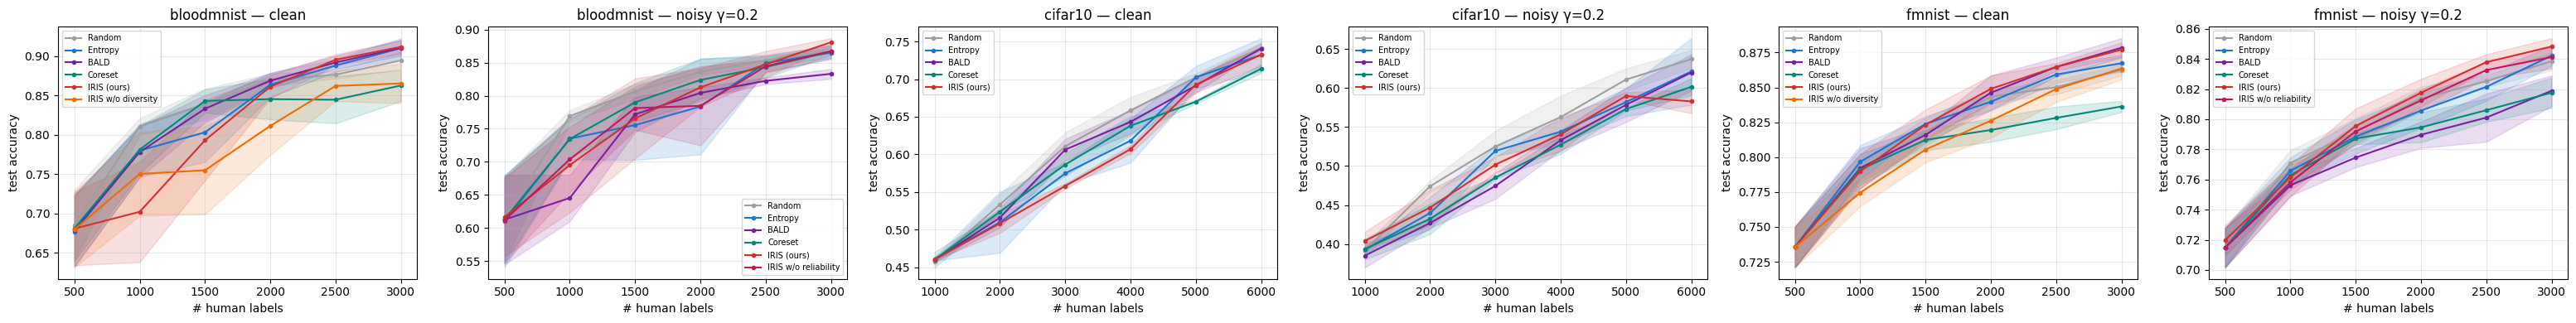

In [5]:
# Learning curves: accuracy vs annotation budget (mean ± std over seeds)
import matplotlib.pyplot as plt

METHOD_ORDER = ["random", "entropy", "bald", "coreset", "iris",
                "iris-nodiv", "iris-norel"]
LAB = {"random": "Random", "entropy": "Entropy", "bald": "BALD",
       "coreset": "Coreset", "iris": "IRIS (ours)",
       "iris-nodiv": "IRIS w/o diversity", "iris-norel": "IRIS w/o reliability"}
COL = {"random": "#9e9e9e", "entropy": "#1976d2", "bald": "#7b1fa2",
       "coreset": "#00897b", "iris": "#d32f2f",
       "iris-nodiv": "#ef6c00", "iris-norel": "#c2185b"}

if df is not None:
    combos = [(ds, nz) for ds in sorted(df.dataset.unique())
              for nz in sorted(df[df.dataset == ds].noise.unique())]
    fig, axes = plt.subplots(1, len(combos), figsize=(5.2 * len(combos), 4),
                             squeeze=False)
    for ax, (ds, nz) in zip(axes[0], combos):
        sub = df[(df.dataset == ds) & (df.noise == nz)]
        for m in METHOD_ORDER:
            g = sub[sub.method == m]
            if g.empty:
                continue
            piv = g.pivot_table(index="n_labeled", columns="seed", values="test_acc")
            mean, std = piv.mean(1), piv.std(1).fillna(0)
            ax.plot(piv.index, mean, "o-", ms=3, color=COL[m], label=LAB[m])
            ax.fill_between(piv.index, mean - std, mean + std, color=COL[m], alpha=0.15)
        ax.set_title(f"{ds} — {'clean' if nz == 0 else f'noisy γ={nz}'}")
        ax.set_xlabel("# human labels"); ax.set_ylabel("test accuracy")
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

In [6]:
# Summary table: final accuracy and AUBC per method/setting
import numpy as np

def aubc(n, a):
    n, a = np.asarray(n, float), np.asarray(a, float)
    o = np.argsort(n)
    return np.trapezoid(a[o], n[o]) / (n[o][-1] - n[o][0])

if df is not None:
    rows = []
    for (ds, nz, m), g in df.groupby(["dataset", "noise", "method"]):
        piv = g.pivot_table(index="n_labeled", columns="seed", values="test_acc")
        aubcs = [aubc(piv.index, piv[c].values) for c in piv.columns]
        finals = piv.loc[piv.index.max()].values
        rows.append(dict(dataset=ds, noise=nz, method=LAB.get(m, m),
                         final_acc=f"{100*np.mean(finals):.2f} ± {100*np.std(finals):.2f}",
                         AUBC=f"{100*np.mean(aubcs):.2f} ± {100*np.std(aubcs):.2f}"))
    display(pd.DataFrame(rows).sort_values(["dataset", "noise"]).reset_index(drop=True))

,dataset,noise,method,final_acc,AUBC
0,bloodmnist,0.0,BALD,91.05 ± 0.91,83.32 ± 1.30
1,bloodmnist,0.0,Coreset,86.26 ± 1.80,81.71 ± 0.77
2,bloodmnist,0.0,Entropy,91.00 ± 1.16,82.55 ± 1.18
3,bloodmnist,0.0,IRIS (ours),91.16 ± 0.77,80.95 ± 0.82
4,bloodmnist,0.0,IRIS w/o diversity,86.52 ± 2.30,79.01 ± 1.45
5,bloodmnist,0.0,Random,89.45 ± 1.03,83.70 ± 0.41
6,bloodmnist,0.2,BALD,83.31 ± 0.69,75.34 ± 0.92
7,bloodmnist,0.2,Coreset,86.68 ± 0.46,78.63 ± 0.61
8,bloodmnist,0.2,Entropy,86.50 ± 0.91,77.22 ± 1.02
9,bloodmnist,0.2,IRIS (ours),88.08 ± 0.56,77.39 ± 1.02


In [7]:
# Diagnostic: does the introspection head out-rank entropy at error prediction?
diag_path = os.path.join(RESULTS_DIR, "diagnostics.csv")
if os.path.exists(diag_path):
    dg = pd.read_csv(diag_path)
    dg = dg[(dg.method == "iris")]
    piv = dg.groupby(["dataset", "round"])[
        ["auroc_introspection", "auroc_entropy"]].mean().round(4)
    display(piv)
else:
    print("diagnostics.csv not found yet")

auroc_introspection  auroc_entropy
dataset    round                                    
bloodmnist 0                   0.7469         0.7607
           1                   0.7282         0.7691
           2                   0.7702         0.8248
           3                   0.7873         0.8514
           4                   0.8128         0.8760
           5                   0.8318         0.8922
cifar10    0                   0.6123         0.6831
           1                   0.5980         0.6892
           2                   0.6239         0.7102
           3                   0.6312         0.7255
           4                   0.6732         0.7546
           5                   0.6748         0.7632
fmnist     0                   0.7601         0.8208
           1                   0.7490         0.8275
           2                   0.7442         0.8307
           3                   0.7420         0.8365
           4                   0.7533         0.8487
           5                   0.7594         0.8529

## 5. Where everything lives
- **Paper draft (PDF):** `latex/main.pdf` — numbers/figures auto-filled from
  `results/` by `code/make_numbers.py` + `code/make_plots.py` (rerun by
  `code/finalize.sh`).
- **Literature review:** `literature_review/literature_review.md` (15+ sources incl.
  six 2026 Nature-portfolio papers and six 2026 Springer/Elsevier Q1 papers, all PDFs
  in `papers/`).
- **Reproduce from scratch:** run section 3, wait for `ALL RUNS COMPLETE` in
  `logs/experiments.log`, then re-run section 4 here.
